In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [3]:
DATABASE_URL = os.getenv(
    "FINPULSE_DATABASE_URL",
    (
        "postgresql+psycopg2://"
        "finpulse_user:finpulse_password"
        "@postgres:5432/finpulse"
    ),
)

engine = create_engine(DATABASE_URL)

query = """
SELECT *
FROM marts.mart_customer_churn_model
ORDER BY customer_id
"""

model_data = pd.read_sql(query, engine)

print(f"Linhas: {model_data.shape[0]:,}")
print(f"Colunas: {model_data.shape[1]}")
display(model_data.head())

Linhas: 10,127
Colunas: 21


,customer_id,churn_flag,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_last_12m,contacts_count_last_12m,credit_limit,total_revolving_balance,average_open_to_buy,amount_change_q4_q1,total_transaction_amount,total_transaction_count,transaction_count_change_q4_q1,average_utilization_ratio
0,708082083,0,45,F,3,High School,Married,Less than $40K,Blue,36,4,3,3,"3,544.0000","1,661.0000","1,883.0000",0.8310,"15,149.0000",111,0.7340,0.4690
1,708083283,1,58,M,0,Unknown,Single,$40K - $60K,Blue,45,3,1,3,"3,421.0000","2,517.0000",904.0000,0.9920,992.0000,21,0.4000,0.7360
2,708084558,1,46,M,3,Doctorate,Divorced,$80K - $120K,Blue,38,6,3,3,"8,258.0000","1,771.0000","6,487.0000",0.0000,"1,447.0000",23,0.0000,0.2140
3,708085458,0,34,F,2,Uneducated,Single,Less than $40K,Blue,24,6,2,2,"1,438.3000",0.0000,"1,438.3000",0.8270,"3,940.0000",82,0.9520,0.0000
4,708086958,0,49,F,2,Uneducated,Married,Unknown,Blue,41,3,5,2,"3,128.0000",749.0000,"2,379.0000",0.5980,"4,369.0000",59,0.7350,0.2390


In [4]:
assert len(model_data) == 10_127
assert model_data["customer_id"].nunique() == 10_127
assert model_data["churn_flag"].isin([0, 1]).all()
assert not model_data.columns.str.contains(
    "naive_bayes",
    case=False,
).any()
assert "attrition_status" not in model_data.columns

print("Model mart validation passed.")

Model mart validation passed.


In [5]:
train_data, test_data = train_test_split(
    model_data,
    test_size=0.20,
    stratify=model_data["churn_flag"],
    random_state=RANDOM_STATE,
)

feature_columns = [
    column
    for column in model_data.columns
    if column not in ["customer_id", "churn_flag"]
]

X_train = train_data[feature_columns].copy()
y_train = train_data["churn_flag"].copy()

X_test = test_data[feature_columns].copy()
y_test = test_data["churn_flag"].copy()

test_customer_ids = test_data["customer_id"].copy()

split_summary = pd.DataFrame(
    {
        "rows": [len(train_data), len(test_data)],
        "churn_rate": [
            y_train.mean(),
            y_test.mean(),
        ],
    },
    index=["train", "test"],
)

display(split_summary)

,rows,churn_rate
train,8101,0.1607
test,2026,0.1604


In [6]:
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

In [7]:
def evaluate_predictions(
    model_name,
    y_true,
    probabilities,
    threshold=0.50,
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    return pd.DataFrame(
        {
            "model": [model_name],
            "threshold": [threshold],
            "roc_auc": [
                roc_auc_score(y_true, probabilities)
            ],
            "average_precision": [
                average_precision_score(
                    y_true,
                    probabilities,
                )
            ],
            "accuracy": [
                accuracy_score(y_true, predictions)
            ],
            "balanced_accuracy": [
                balanced_accuracy_score(
                    y_true,
                    predictions,
                )
            ],
            "precision": [
                precision_score(
                    y_true,
                    predictions,
                    zero_division=0,
                )
            ],
            "recall": [
                recall_score(
                    y_true,
                    predictions,
                    zero_division=0,
                )
            ],
            "f1": [
                f1_score(
                    y_true,
                    predictions,
                    zero_division=0,
                )
            ],
        }
    )

In [8]:
dummy_model = DummyClassifier(
    strategy="prior",
)

dummy_X_train = np.zeros(
    shape=(len(y_train), 1)
)

dummy_X_test = np.zeros(
    shape=(len(y_test), 1)
)

dummy_model.fit(
    dummy_X_train,
    y_train,
)

dummy_probabilities = dummy_model.predict_proba(
    dummy_X_test
)[:, 1]

dummy_results = evaluate_predictions(
    model_name="Dummy Classifier",
    y_true=y_test,
    probabilities=dummy_probabilities,
)

display(dummy_results.round(4))

,model,threshold,roc_auc,average_precision,accuracy,balanced_accuracy,precision,recall,f1
0,Dummy Classifier,0.5000,0.5000,0.1604,0.8396,0.5000,0.0000,0.0000,0.0000


In [9]:
categorical_features = (
    X_train
    .select_dtypes(exclude="number")
    .columns
    .tolist()
)

numeric_features = (
    X_train
    .select_dtypes(include="number")
    .columns
    .tolist()
)

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

print(
    f"\nTotal features: "
    f"{len(categorical_features) + len(numeric_features)}"
)

Categorical features:
['gender', 'education_level', 'marital_status', 'income_category', 'card_category']

Numeric features:
['customer_age', 'dependent_count', 'months_on_book', 'total_relationship_count', 'months_inactive_last_12m', 'contacts_count_last_12m', 'credit_limit', 'total_revolving_balance', 'average_open_to_buy', 'amount_change_q4_q1', 'total_transaction_amount', 'total_transaction_count', 'transaction_count_change_q4_q1', 'average_utilization_ratio']

Total features: 19


In [10]:
train_data, validation_data = train_test_split(
    train_data,
    test_size=0.25,
    stratify=train_data["churn_flag"],
    random_state=RANDOM_STATE,
)

X_train = train_data[feature_columns].copy()
y_train = train_data["churn_flag"].copy()

X_validation = validation_data[feature_columns].copy()
y_validation = validation_data["churn_flag"].copy()

X_test = test_data[feature_columns].copy()
y_test = test_data["churn_flag"].copy()

test_customer_ids = test_data["customer_id"].copy()

split_summary = pd.DataFrame(
    {
        "rows": [
            len(train_data),
            len(validation_data),
            len(test_data),
        ],
        "churn_rate": [
            y_train.mean(),
            y_validation.mean(),
            y_test.mean(),
        ],
    },
    index=["train", "validation", "test"],
)

display(split_summary)

,rows,churn_rate
train,6075,0.1607
validation,2026,0.1609
test,2026,0.1604


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [12]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)

In [13]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2_000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logistic_model.fit(
    X_train,
    y_train,
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['customer_age',
                                                   'dependent_count',
                                                   'months_on_book',
                                                   'total_relationship_count',
                                                   'months_inactive_last_12m',
                                                   'contacts_count_last_12m',
                                                   'credit_limit',
                                                   'total_revolving_balance',
                                                   'average_ope...
                                                   'total_transaction_count',
                                                   'transaction_count_change_q4_q1',
                                                   'average_utilization_ratio']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'education_level',
                                                   'marital_status',
                                                   'income_category',
                                                   'card_category'])])),
                ('classifier',
                 LogisticRegression(max_iter=2000, random_state=42))])

In [14]:
logistic_validation_probabilities = (
    logistic_model.predict_proba(
        X_validation
    )[:, 1]
)

logistic_validation_results = evaluate_predictions(
    model_name="Logistic Regression",
    y_true=y_validation,
    probabilities=logistic_validation_probabilities,
)

display(
    logistic_validation_results.round(4)
)

,model,threshold,roc_auc,average_precision,accuracy,balanced_accuracy,precision,recall,f1
0,Logistic Regression,0.5000,0.9307,0.7662,0.9102,0.7878,0.7857,0.6074,0.6851


In [15]:
pip install lightgbm


Note: you may need to restart the kernel to use updated packages.


In [16]:
import time

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [17]:
numeric_benchmark_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_benchmark_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

benchmark_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_benchmark_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_benchmark_pipeline,
            categorical_features,
        ),
    ],
    sparse_threshold=0,
)

In [18]:
model_definitions = {
    "Logistic Regression": LogisticRegression(
        max_iter=2_000,
        random_state=RANDOM_STATE,
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=25,
        weights="distance",
        n_jobs=-1,
    ),

    "Gaussian Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        min_samples_leaf=3,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=250,
        min_samples_leaf=3,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=250,
        max_leaf_nodes=15,
        min_samples_leaf=30,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    ),

    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=3,
        subsample=0.80,
        colsample_bytree=0.80,
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=15,
        max_depth=-1,
        min_child_samples=30,
        subsample=0.80,
        colsample_bytree=0.80,
        verbosity=-1,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "CatBoost": CatBoostClassifier(
        iterations=400,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        verbose=0,
        thread_count=-1,
        allow_writing_files=False,
        random_seed=RANDOM_STATE,
    ),
}

In [19]:
benchmark_results = []
trained_models = {}

dummy_start = time.perf_counter()

dummy_model = DummyClassifier(
    strategy="prior",
)

dummy_model.fit(
    np.zeros((len(y_train), 1)),
    y_train,
)

dummy_validation_probabilities = (
    dummy_model.predict_proba(
        np.zeros((len(y_validation), 1))
    )[:, 1]
)

dummy_result = evaluate_predictions(
    model_name="Dummy Classifier",
    y_true=y_validation,
    probabilities=dummy_validation_probabilities,
)

dummy_result["training_seconds"] = (
    time.perf_counter() - dummy_start
)

benchmark_results.append(dummy_result)

for model_name, classifier in model_definitions.items():
    print(f"Training: {model_name}")

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(benchmark_preprocessor),
            ),
            (
                "classifier",
                classifier,
            ),
        ]
    )

    start_time = time.perf_counter()

    try:
        model_pipeline.fit(
            X_train,
            y_train,
        )

        validation_probabilities = (
            model_pipeline.predict_proba(
                X_validation
            )[:, 1]
        )

        model_result = evaluate_predictions(
            model_name=model_name,
            y_true=y_validation,
            probabilities=validation_probabilities,
        )

        model_result["training_seconds"] = (
            time.perf_counter() - start_time
        )

        benchmark_results.append(model_result)
        trained_models[model_name] = model_pipeline

        print(
            f"Completed: {model_name} "
            f"({model_result['training_seconds'].iloc[0]:.2f}s)"
        )

    except Exception as error:
        print(f"Failed: {model_name}")
        print(error)

Training: Logistic Regression
Completed: Logistic Regression (0.07s)
Training: K-Nearest Neighbors
Completed: K-Nearest Neighbors (0.12s)
Training: Gaussian Naive Bayes
Completed: Gaussian Naive Bayes (0.05s)
Training: Decision Tree
Completed: Decision Tree (0.08s)
Training: Random Forest
Completed: Random Forest (1.43s)
Training: Extra Trees
Completed: Extra Trees (1.28s)
Training: HistGradientBoosting
Completed: HistGradientBoosting (0.57s)
Training: XGBoost
Completed: XGBoost (0.91s)
Training: LightGBM
Completed: LightGBM (1.09s)
Training: CatBoost
Completed: CatBoost (0.81s)


In [20]:
model_comparison = (
    pd.concat(
        benchmark_results,
        ignore_index=True,
    )
    .sort_values(
        by=[
            "average_precision",
            "roc_auc",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

model_comparison.insert(
    0,
    "ranking",
    range(1, len(model_comparison) + 1),
)

display(
    model_comparison[
        [
            "ranking",
            "model",
            "roc_auc",
            "average_precision",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "training_seconds",
        ]
    ].round(4)
)

,ranking,model,roc_auc,average_precision,accuracy,balanced_accuracy,precision,recall,f1,training_seconds
0,1,CatBoost,0.9957,0.9827,0.9803,0.9610,0.9441,0.9325,0.9383,0.8147
1,2,LightGBM,0.9958,0.9825,0.9812,0.9616,0.9500,0.9325,0.9412,1.0870
2,3,HistGradientBoosting,0.9953,0.9810,0.9778,0.9545,0.9404,0.9202,0.9302,0.5714
3,4,XGBoost,0.9952,0.9808,0.9778,0.9570,0.9350,0.9264,0.9307,0.9149
4,5,Random Forest,0.9887,0.9504,0.9546,0.8886,0.9149,0.7914,0.8487,1.4268
5,6,Extra Trees,0.9782,0.8988,0.9166,0.7544,0.9385,0.5153,0.6653,1.2831
6,7,Decision Tree,0.9552,0.8621,0.9358,0.8601,0.8356,0.7485,0.7896,0.0787
7,8,K-Nearest Neighbors,0.9544,0.8207,0.9033,0.7267,0.8736,0.4663,0.6080,0.1215
8,9,Logistic Regression,0.9307,0.7662,0.9102,0.7878,0.7857,0.6074,0.6851,0.0709
9,10,Gaussian Naive Bayes,0.8572,0.5862,0.8796,0.7646,0.6340,0.5951,0.6139,0.0540


In [21]:
overfitting_rows = []

for model_name, model_pipeline in trained_models.items():
    train_probabilities = (
        model_pipeline.predict_proba(
            X_train
        )[:, 1]
    )

    validation_probabilities = (
        model_pipeline.predict_proba(
            X_validation
        )[:, 1]
    )

    train_metrics = evaluate_predictions(
        model_name=model_name,
        y_true=y_train,
        probabilities=train_probabilities,
    ).iloc[0]

    validation_metrics = evaluate_predictions(
        model_name=model_name,
        y_true=y_validation,
        probabilities=validation_probabilities,
    ).iloc[0]

    overfitting_rows.append(
        {
            "model": model_name,

            "train_roc_auc": train_metrics["roc_auc"],
            "validation_roc_auc": validation_metrics["roc_auc"],
            "roc_auc_gap": (
                train_metrics["roc_auc"]
                - validation_metrics["roc_auc"]
            ),

            "train_average_precision": (
                train_metrics["average_precision"]
            ),
            "validation_average_precision": (
                validation_metrics["average_precision"]
            ),
            "average_precision_gap": (
                train_metrics["average_precision"]
                - validation_metrics["average_precision"]
            ),

            "train_f1": train_metrics["f1"],
            "validation_f1": validation_metrics["f1"],
            "f1_gap": (
                train_metrics["f1"]
                - validation_metrics["f1"]
            ),
        }
    )

overfitting_comparison = (
    pd.DataFrame(overfitting_rows)
    .sort_values(
        "validation_average_precision",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    overfitting_comparison.round(4)
)

,model,train_roc_auc,validation_roc_auc,roc_auc_gap,train_average_precision,validation_average_precision,average_precision_gap,train_f1,validation_f1,f1_gap
0,CatBoost,0.9998,0.9957,0.0041,0.9989,0.9827,0.0162,0.9836,0.9383,0.0453
1,LightGBM,1.0000,0.9958,0.0042,1.0000,0.9825,0.0175,1.0000,0.9412,0.0588
2,HistGradientBoosting,0.9997,0.9953,0.0044,0.9986,0.9810,0.0176,0.9851,0.9302,0.0549
3,XGBoost,0.9995,0.9952,0.0043,0.9976,0.9808,0.0168,0.9763,0.9307,0.0457
4,Random Forest,0.9995,0.9887,0.0108,0.9976,0.9504,0.0472,0.9679,0.8487,0.1193
5,Extra Trees,0.9995,0.9782,0.0213,0.9973,0.8988,0.0984,0.9219,0.6653,0.2565
6,Decision Tree,0.9818,0.9552,0.0266,0.9197,0.8621,0.0576,0.8319,0.7896,0.0423
7,K-Nearest Neighbors,1.0000,0.9544,0.0456,1.0000,0.8207,0.1793,1.0000,0.6080,0.3920
8,Logistic Regression,0.9229,0.9307,-0.0078,0.7589,0.7662,-0.0072,0.6565,0.6851,-0.0286
9,Gaussian Naive Bayes,0.8673,0.8572,0.0101,0.6135,0.5862,0.0274,0.6088,0.6139,-0.0051


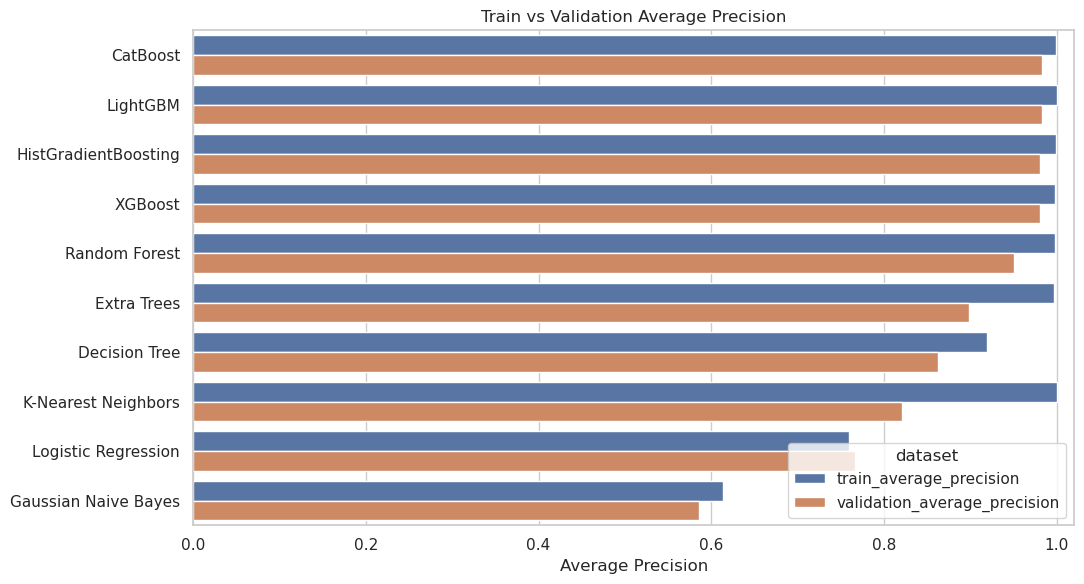

In [22]:
ap_comparison = (
    overfitting_comparison[
        [
            "model",
            "train_average_precision",
            "validation_average_precision",
        ]
    ]
    .melt(
        id_vars="model",
        var_name="dataset",
        value_name="average_precision",
    )
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=ap_comparison,
    y="model",
    x="average_precision",
    hue="dataset",
)

plt.title("Train vs Validation Average Precision")
plt.xlabel("Average Precision")
plt.ylabel("")
plt.xlim(0, 1.02)
plt.tight_layout()
plt.show()

In [23]:
train_fingerprints = set(
    pd.util.hash_pandas_object(
        X_train,
        index=False,
    )
)

validation_fingerprints = set(
    pd.util.hash_pandas_object(
        X_validation,
        index=False,
    )
)

shared_feature_rows = (
    train_fingerprints
    & validation_fingerprints
)

print(
    "Exact feature rows shared between "
    f"train and validation: {len(shared_feature_rows)}"
)

Exact feature rows shared between train and validation: 0


In [24]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)

In [25]:
development_data = pd.concat(
    [
        train_data,
        validation_data,
    ],
    ignore_index=True,
)

X_development = development_data[
    feature_columns
].copy()

y_development = development_data[
    "churn_flag"
].copy()

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

top_model_names = [
    "CatBoost",
    "LightGBM",
    "HistGradientBoosting",
    "XGBoost",
]

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
}

cross_validation_rows = []

for model_name in top_model_names:
    print(f"Cross-validating: {model_name}")

    cv_result = cross_validate(
        estimator=trained_models[model_name],
        X=X_development,
        y=y_development,
        cv=cross_validation,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )

    cross_validation_rows.append(
        {
            "model": model_name,
            "roc_auc_mean": (
                cv_result["test_roc_auc"].mean()
            ),
            "roc_auc_std": (
                cv_result["test_roc_auc"].std()
            ),
            "average_precision_mean": (
                cv_result[
                    "test_average_precision"
                ].mean()
            ),
            "average_precision_std": (
                cv_result[
                    "test_average_precision"
                ].std()
            ),
            "balanced_accuracy_mean": (
                cv_result[
                    "test_balanced_accuracy"
                ].mean()
            ),
            "f1_mean": (
                cv_result["test_f1"].mean()
            ),
            "fit_time_mean": (
                cv_result["fit_time"].mean()
            ),
        }
    )

cross_validation_summary = (
    pd.DataFrame(cross_validation_rows)
    .sort_values(
        [
            "average_precision_mean",
            "roc_auc_mean",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    cross_validation_summary.round(4)
)

Cross-validating: CatBoost
Cross-validating: LightGBM
Cross-validating: HistGradientBoosting
Cross-validating: XGBoost


,model,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,balanced_accuracy_mean,f1_mean,fit_time_mean
0,CatBoost,0.9946,0.0014,0.9754,0.0086,0.9382,0.9144,0.7279
1,LightGBM,0.9945,0.0014,0.9751,0.0072,0.9424,0.9160,0.5613
2,HistGradientBoosting,0.9937,0.0012,0.9725,0.0068,0.9404,0.9139,0.4045
3,XGBoost,0.9937,0.0012,0.9721,0.0073,0.9394,0.9133,0.4921


In [26]:
from sklearn.inspection import permutation_importance

In [27]:
catboost_candidate = trained_models["CatBoost"]

permutation_result = permutation_importance(
    estimator=catboost_candidate,
    X=X_validation,
    y=y_validation,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

feature_importance = (
    pd.DataFrame(
        {
            "feature": feature_columns,
            "importance_mean": (
                permutation_result.importances_mean
            ),
            "importance_std": (
                permutation_result.importances_std
            ),
        }
    )
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    feature_importance.round(4)
)

,feature,importance_mean,importance_std
0,total_transaction_count,0.5744,0.0282
1,total_transaction_amount,0.3264,0.0196
2,total_relationship_count,0.0316,0.0051
3,total_revolving_balance,0.0278,0.0047
4,amount_change_q4_q1,0.0256,0.0036
5,transaction_count_change_q4_q1,0.0149,0.0028
6,customer_age,0.0096,0.0013
7,contacts_count_last_12m,0.0051,0.0015
8,months_inactive_last_12m,0.0050,0.0014
9,credit_limit,0.0020,0.0005


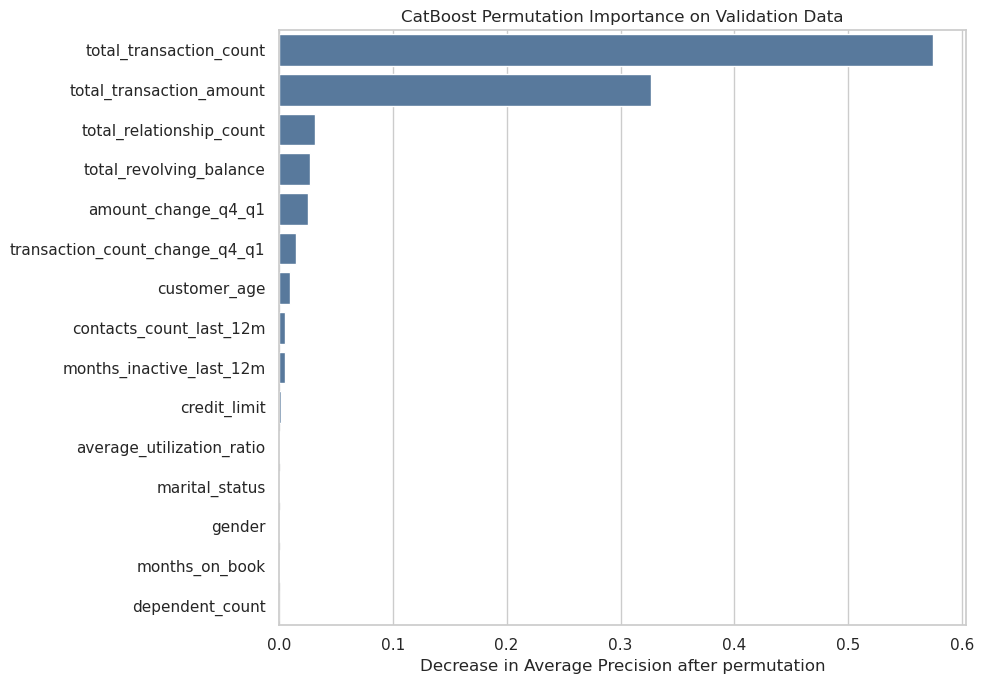

In [28]:
top_feature_importance = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_feature_importance,
    x="importance_mean",
    y="feature",
    color="#4C78A8",
)

plt.title(
    "CatBoost Permutation Importance "
    "on Validation Data"
)
plt.xlabel(
    "Decrease in Average Precision "
    "after permutation"
)
plt.ylabel("")
plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import precision_recall_curve

In [30]:
catboost_validation_probabilities = (
    catboost_candidate.predict_proba(
        X_validation
    )[:, 1]
)

precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_validation,
        catboost_validation_probabilities,
    )
)

threshold_metrics = pd.DataFrame(
    {
        "threshold": thresholds,
        "precision": precision_values[:-1],
        "recall": recall_values[:-1],
    }
)

threshold_metrics["f1"] = (
    2
    * threshold_metrics["precision"]
    * threshold_metrics["recall"]
    / (
        threshold_metrics["precision"]
        + threshold_metrics["recall"]
    ).replace(0, np.nan)
)

threshold_metrics = threshold_metrics.dropna()

best_f1_row = (
    threshold_metrics
    .sort_values(
        "f1",
        ascending=False,
    )
    .iloc[0]
)

print("Best validation threshold by F1:")
display(best_f1_row.to_frame().T.round(4))

Best validation threshold by F1:


,threshold,precision,recall,f1
1702,0.4762,0.9444,0.9387,0.9415


In [31]:
retention_candidates = threshold_metrics[
    threshold_metrics["precision"] >= 0.80
]

retention_threshold_row = (
    retention_candidates
    .sort_values(
        [
            "recall",
            "f1",
        ],
        ascending=False,
    )
    .iloc[0]
)

print(
    "Retention-oriented threshold "
    "with precision >= 80%:"
)

display(
    retention_threshold_row
    .to_frame()
    .T
    .round(4)
)

Retention-oriented threshold with precision >= 80%:


,threshold,precision,recall,f1
1658,0.2075,0.8641,0.9755,0.9164


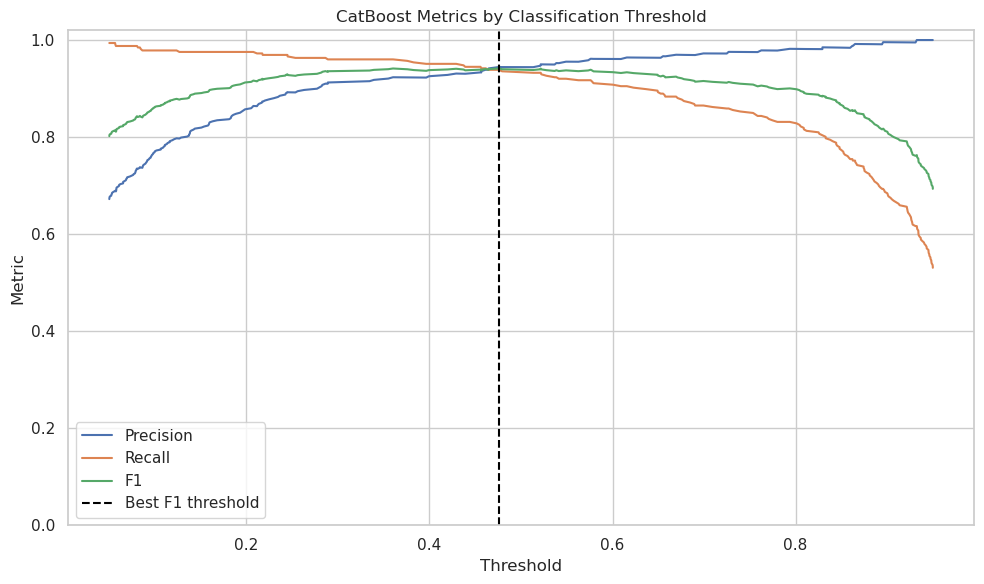

In [32]:
threshold_plot_data = threshold_metrics[
    threshold_metrics["threshold"]
    .between(0.05, 0.95)
]

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_plot_data["threshold"],
    threshold_plot_data["precision"],
    label="Precision",
)

plt.plot(
    threshold_plot_data["threshold"],
    threshold_plot_data["recall"],
    label="Recall",
)

plt.plot(
    threshold_plot_data["threshold"],
    threshold_plot_data["f1"],
    label="F1",
)

plt.axvline(
    best_f1_row["threshold"],
    color="black",
    linestyle="--",
    label="Best F1 threshold",
)

plt.title("CatBoost Metrics by Classification Threshold")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
classification_threshold = float(
    best_f1_row["threshold"]
)

watchlist_threshold = float(
    retention_threshold_row["threshold"]
)

print(
    f"Classification threshold: "
    f"{classification_threshold:.4f}"
)

print(
    f"Watchlist threshold: "
    f"{watchlist_threshold:.4f}"
)

Classification threshold: 0.4762
Watchlist threshold: 0.2075


In [34]:
development_data = pd.concat(
    [
        train_data,
        validation_data,
    ],
    ignore_index=True,
)

X_development = development_data[
    feature_columns
].copy()

y_development = development_data[
    "churn_flag"
].copy()

print(f"Development rows: {len(X_development):,}")
print(f"Final test rows: {len(X_test):,}")

Development rows: 8,101
Final test rows: 2,026


In [35]:
from sklearn.base import clone

final_catboost_model = clone(
    trained_models["CatBoost"]
)

final_catboost_model.fit(
    X_development,
    y_development,
)

print("Final CatBoost training completed.")

Final CatBoost training completed.


In [36]:
final_test_probabilities = (
    final_catboost_model.predict_proba(
        X_test
    )[:, 1]
)

In [37]:
final_test_results = pd.concat(
    [
        evaluate_predictions(
            model_name="CatBoost - Default",
            y_true=y_test,
            probabilities=final_test_probabilities,
            threshold=0.50,
        ),
        evaluate_predictions(
            model_name="CatBoost - Best F1",
            y_true=y_test,
            probabilities=final_test_probabilities,
            threshold=classification_threshold,
        ),
        evaluate_predictions(
            model_name="CatBoost - Watchlist",
            y_true=y_test,
            probabilities=final_test_probabilities,
            threshold=watchlist_threshold,
        ),
    ],
    ignore_index=True,
)

display(
    final_test_results.round(4)
)

,model,threshold,roc_auc,average_precision,accuracy,balanced_accuracy,precision,recall,f1
0,CatBoost - Default,0.5000,0.9934,0.9699,0.9748,0.9390,0.9536,0.8862,0.9187
1,CatBoost - Best F1,0.4762,0.9934,0.9699,0.9753,0.9417,0.9508,0.8923,0.9206
2,CatBoost - Watchlist,0.2075,0.9934,0.9699,0.9635,0.9558,0.8457,0.9446,0.8924


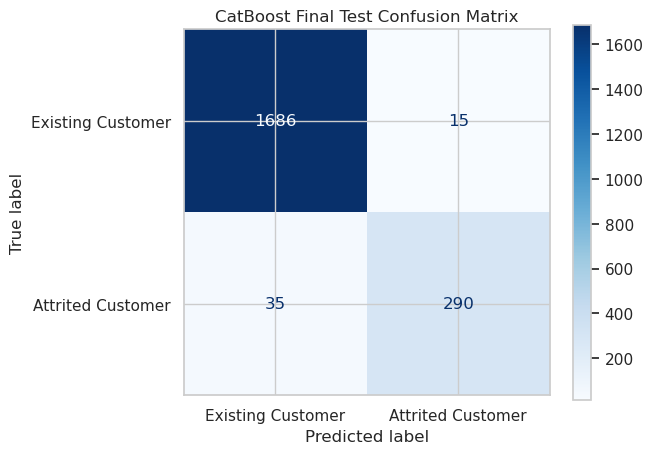

In [38]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
)

final_test_predictions = (
    final_test_probabilities
    >= classification_threshold
).astype(int)

final_confusion_matrix = confusion_matrix(
    y_test,
    final_test_predictions,
)

ConfusionMatrixDisplay(
    confusion_matrix=final_confusion_matrix,
    display_labels=[
        "Existing Customer",
        "Attrited Customer",
    ],
).plot(
    cmap="Blues",
    values_format="d",
)

plt.title(
    "CatBoost Final Test Confusion Matrix"
)
plt.tight_layout()
plt.show()

In [39]:
import mlflow

mlflow.set_tracking_uri(
    "http://mlflow:5000"
)

if mlflow.active_run() is not None:
    mlflow.end_run()

benchmark_experiment = mlflow.set_experiment(
    "finpulse-churn-benchmark"
)

print(
    "Experiment:",
    benchmark_experiment.name,
)

print(
    "Experiment ID:",
    benchmark_experiment.experiment_id,
)

Experiment: finpulse-churn-benchmark
Experiment ID: 3


In [40]:
overfitting_lookup = (
    overfitting_comparison
    .set_index("model")
)

cross_validation_lookup = (
    cross_validation_summary
    .set_index("model")
)

In [41]:
def make_mlflow_safe(value):
    if isinstance(
        value,
        (
            str,
            int,
            float,
            bool,
        ),
    ):
        return value

    if value is None:
        return "None"

    return str(value)

In [42]:
validation_metric_names = [
    "roc_auc",
    "average_precision",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "training_seconds",
]

for _, result_row in model_comparison.iterrows():
    model_name = result_row["model"]

    print(f"Logging: {model_name}")

    with mlflow.start_run(
        run_name=model_name
    ):
        mlflow.set_tags(
            {
                "project": "FinPulse AI",
                "task": "bank_customer_churn",
                "phase": "benchmark",
                "dataset": "BankChurners",
                "source_mart": (
                    "marts."
                    "mart_customer_churn_model"
                ),
            }
        )

        mlflow.log_params(
            {
                "random_state": RANDOM_STATE,
                "train_rows": len(X_train),
                "validation_rows": len(
                    X_validation
                ),
                "feature_count": len(
                    feature_columns
                ),
                "threshold": float(
                    result_row["threshold"]
                ),
            }
        )

        if model_name in model_definitions:
            model_parameters = (
                model_definitions[model_name]
                .get_params(deep=False)
            )

            safe_parameters = {
                f"classifier__{name}": (
                    make_mlflow_safe(value)
                )
                for name, value
                in model_parameters.items()
            }

            mlflow.log_params(
                safe_parameters
            )

        elif model_name == "Dummy Classifier":
            mlflow.log_param(
                "classifier__strategy",
                "prior",
            )

        validation_metrics = {
            f"validation_{metric_name}": float(
                result_row[metric_name]
            )
            for metric_name
            in validation_metric_names
        }

        mlflow.log_metrics(
            validation_metrics
        )

        if model_name in overfitting_lookup.index:
            overfitting_row = (
                overfitting_lookup.loc[
                    model_name
                ]
            )

            mlflow.log_metrics(
                {
                    "train_roc_auc": float(
                        overfitting_row[
                            "train_roc_auc"
                        ]
                    ),
                    "roc_auc_gap": float(
                        overfitting_row[
                            "roc_auc_gap"
                        ]
                    ),
                    "train_average_precision": float(
                        overfitting_row[
                            "train_average_precision"
                        ]
                    ),
                    "average_precision_gap": float(
                        overfitting_row[
                            "average_precision_gap"
                        ]
                    ),
                    "train_f1": float(
                        overfitting_row[
                            "train_f1"
                        ]
                    ),
                    "f1_gap": float(
                        overfitting_row[
                            "f1_gap"
                        ]
                    ),
                }
            )

        if model_name in cross_validation_lookup.index:
            cv_row = (
                cross_validation_lookup.loc[
                    model_name
                ]
            )

            mlflow.log_metrics(
                {
                    "cv_roc_auc_mean": float(
                        cv_row["roc_auc_mean"]
                    ),
                    "cv_roc_auc_std": float(
                        cv_row["roc_auc_std"]
                    ),
                    "cv_average_precision_mean": float(
                        cv_row[
                            "average_precision_mean"
                        ]
                    ),
                    "cv_average_precision_std": float(
                        cv_row[
                            "average_precision_std"
                        ]
                    ),
                    "cv_balanced_accuracy_mean": float(
                        cv_row[
                            "balanced_accuracy_mean"
                        ]
                    ),
                    "cv_f1_mean": float(
                        cv_row["f1_mean"]
                    ),
                }
            )

print("Benchmark runs logged successfully.")

Logging: CatBoost
🏃 View run CatBoost at: http://mlflow:5000/#/experiments/3/runs/f3c719aaa85b4441b4e01e135af378ba
🧪 View experiment at: http://mlflow:5000/#/experiments/3
Logging: LightGBM
🏃 View run LightGBM at: http://mlflow:5000/#/experiments/3/runs/75040856847d4042b1ade695db6d1bad
🧪 View experiment at: http://mlflow:5000/#/experiments/3
Logging: HistGradientBoosting
🏃 View run HistGradientBoosting at: http://mlflow:5000/#/experiments/3/runs/b05ba7cd7faf46c2b4721ba5699ea6f0
🧪 View experiment at: http://mlflow:5000/#/experiments/3
Logging: XGBoost
🏃 View run XGBoost at: http://mlflow:5000/#/experiments/3/runs/d9d4221e96a94df6922c6ea9056ed024
🧪 View experiment at: http://mlflow:5000/#/experiments/3
Logging: Random Forest
🏃 View run Random Forest at: http://mlflow:5000/#/experiments/3/runs/98c9b94b107b4d8f975249d39ef2d78c
🧪 View experiment at: http://mlflow:5000/#/experiments/3
Logging: Extra Trees
🏃 View run Extra Trees at: http://mlflow:5000/#/experiments/3/runs/86caf63b424447ad8fc1

In [43]:
import mlflow

mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("finpulse-churn-final")

with mlflow.start_run(
    run_name="data-pipeline-validation"
) as run:
    
    mlflow.log_dict(
        {
            "raw_rows": 10127,
            "staging_rows": 10127,
            "mart_rows": 10127,
            "unique_customers": 10127,
            "churn_customers": 1627,
            "forbidden_columns": [],
            "validation_status": "passed",
        },
        "validation/data_pipeline_validation.json",
    )

    print("Run ID:", run.info.run_id)
    print("Artifact URI:", run.info.artifact_uri)

2026/07/17 19:17:36 INFO mlflow.tracking.fluent: Experiment with name 'finpulse-churn-final' does not exist. Creating a new experiment.


Run ID: b540a32d863747c28fdae3fc98a91fa4
Artifact URI: mlflow-artifacts:/4/b540a32d863747c28fdae3fc98a91fa4/artifacts
🏃 View run data-pipeline-validation at: http://mlflow:5000/#/experiments/4/runs/b540a32d863747c28fdae3fc98a91fa4
🧪 View experiment at: http://mlflow:5000/#/experiments/4


In [44]:
search_terms = (
    "catboost",
    "threshold",
    "final_test",
    "development",
)

for variable_name in sorted(globals()):
    if any(
        term in variable_name.lower()
        for term in search_terms
    ):
        variable_value = globals()[variable_name]

        print(
            f"{variable_name:45} "
            f"type={type(variable_value).__name__:25} "
            f"shape={getattr(variable_value, 'shape', '')}"
        )

CatBoostClassifier                            type=type                      shape=
X_development                                 type=DataFrame                 shape=(8101, 19)
catboost_candidate                            type=Pipeline                  shape=
catboost_validation_probabilities             type=ndarray                   shape=(2026,)
classification_threshold                      type=float                     shape=
development_data                              type=DataFrame                 shape=(8101, 21)
final_catboost_model                          type=Pipeline                  shape=
final_test_predictions                        type=ndarray                   shape=(2026,)
final_test_probabilities                      type=ndarray                   shape=(2026,)
final_test_results                            type=DataFrame                 shape=(3, 9)
retention_threshold_row                       type=Series                    shape=(4,)
threshold_metrics        

In [51]:
import json
import mlflow
import mlflow.sklearn
import sklearn
import catboost
import cloudpickle
import numpy as np
import pandas as pd

from mlflow.models import infer_signature


# Encerra somente alguma tentativa parcial anterior.
if mlflow.active_run() is not None:
    mlflow.end_run(status="FAILED")


mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("finpulse-churn-final")


# Validações antes do registro.
assert len(X_development) == 8_101
assert len(y_development) == 8_101
assert X_development.shape[1] == 19

assert 0 < classification_threshold < 1

assert (
    0
    < watchlist_threshold
    < classification_threshold
)


official_test_result = (
    final_test_results
    .loc[
        final_test_results["model"]
        == "CatBoost - Best F1"
    ]
    .iloc[0]
)


watchlist_test_result = (
    final_test_results
    .loc[
        final_test_results["model"]
        == "CatBoost - Watchlist"
    ]
    .iloc[0]
)


metric_names = [
    "roc_auc",
    "average_precision",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
]


categorical_features_final = (
    X_development
    .select_dtypes(exclude="number")
    .columns
    .tolist()
)


numeric_features_final = (
    X_development
    .select_dtypes(include="number")
    .columns
    .tolist()
)


input_example = (
    X_development
    .head(5)
    .copy()
)


prediction_example = (
    final_catboost_model
    .predict(input_example)
)


model_signature = infer_signature(
    input_example,
    prediction_example,
)


final_test_results_records = json.loads(
    final_test_results.to_json(
        orient="records"
    )
)


print("Preparação para o registro concluída.")
print(
    "Threshold oficial:",
    round(float(classification_threshold), 4),
)
print(
    "Threshold de watchlist:",
    round(float(watchlist_threshold), 4),
)
print(
    "Features categóricas:",
    len(categorical_features_final),
)
print(
    "Features numéricas:",
    len(numeric_features_final),
)

Preparação para o registro concluída.
Threshold oficial: 0.4762
Threshold de watchlist: 0.2075
Features categóricas: 5
Features numéricas: 14


/opt/conda/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [52]:
with mlflow.start_run(
    run_name="catboost-final-test"
) as run:

    mlflow.set_tags(
        {
            "project": "FinPulse AI",
            "problem": "bank_customer_churn",
            "model_status": "champion",
            "selection_metric": "average_precision",
            "data_source": (
                "marts.mart_customer_churn_model"
            ),
            "test_status": "frozen",
            "serialization": "cloudpickle",
        }
    )


    mlflow.log_params(
        {
            "model_family": "CatBoost",
            "development_rows": len(
                X_development
            ),
            "feature_count": (
                X_development.shape[1]
            ),
            "categorical_feature_count": len(
                categorical_features_final
            ),
            "numeric_feature_count": len(
                numeric_features_final
            ),
            "classification_threshold": float(
                classification_threshold
            ),
            "watchlist_threshold": float(
                watchlist_threshold
            ),
        }
    )


    for metric_name in metric_names:

        mlflow.log_metric(
            f"test_{metric_name}",
            float(
                official_test_result[
                    metric_name
                ]
            ),
        )

        mlflow.log_metric(
            f"test_watchlist_{metric_name}",
            float(
                watchlist_test_result[
                    metric_name
                ]
            ),
        )


    mlflow.log_dict(
        {
            "categorical_features": (
                categorical_features_final
            ),
            "numeric_features": (
                numeric_features_final
            ),
            "target": "churn_flag",
            "identifier": "customer_id",
        },
        "metadata/features.json",
    )


    mlflow.log_dict(
        {
            "classification_threshold": float(
                classification_threshold
            ),
            "watchlist_threshold": float(
                watchlist_threshold
            ),
            "risk_bands": {
                "low": {
                    "minimum": 0.0,
                    "maximum_exclusive": float(
                        watchlist_threshold
                    ),
                },
                "medium": {
                    "minimum_inclusive": float(
                        watchlist_threshold
                    ),
                    "maximum_exclusive": float(
                        classification_threshold
                    ),
                },
                "high": {
                    "minimum_inclusive": float(
                        classification_threshold
                    ),
                    "maximum": 1.0,
                },
            },
        },
        "metadata/thresholds.json",
    )


    mlflow.log_dict(
        final_test_results_records,
        "evaluation/final_test_results.json",
    )


    model_info = mlflow.sklearn.log_model(
        sk_model=final_catboost_model,
        name="model",
        signature=model_signature,
        input_example=input_example,
        registered_model_name=(
            "finpulse-churn-catboost"
        ),
        serialization_format=(
            mlflow.sklearn
            .SERIALIZATION_FORMAT_CLOUDPICKLE
        ),
        pip_requirements=[
            f"mlflow=={mlflow.__version__}",
            (
                f"scikit-learn=="
                f"{sklearn.__version__}"
            ),
            f"catboost=={catboost.__version__}",
            (
                f"cloudpickle=="
                f"{cloudpickle.__version__}"
            ),
            f"pandas=={pd.__version__}",
            f"numpy=={np.__version__}",
        ],
    )


    print("Run ID:", run.info.run_id)
    print("Model URI:", model_info.model_uri)
    print(
        "CatBoost final registrado com sucesso."
    )

2026/07/17 19:48:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'finpulse-churn-catboost' already exists. Creating a new version of this model...
2026/07/17 19:48:26 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: finpulse-churn-catboost, version 3
Created version '3' of model 'finpulse-churn-catboost'.


Run ID: aebd3368a75b4f9ca629132e11234b66
Model URI: models:/m-42da499887dd46b19479736991e5cfe8
CatBoost final registrado com sucesso.
🏃 View run catboost-final-test at: http://mlflow:5000/#/experiments/4/runs/aebd3368a75b4f9ca629132e11234b66
🧪 View experiment at: http://mlflow:5000/#/experiments/4


In [53]:
from mlflow import MlflowClient

registered_model_name = (
    "finpulse-churn-catboost"
)

client = MlflowClient()

model_versions = (
    client.search_model_versions(
        f"name='{registered_model_name}'"
    )
)

assert model_versions, (
    "Nenhuma versão registrada foi encontrada."
)

latest_version = max(
    model_versions,
    key=lambda version: int(version.version),
)

registered_model_uri = (
    f"models:/{registered_model_name}/"
    f"{latest_version.version}"
)

print("Versão encontrada:", latest_version.version)
print("Model URI:", registered_model_uri)

loaded_catboost_model = (
    mlflow.sklearn.load_model(
        registered_model_uri
    )
)

original_predictions = (
    final_catboost_model.predict(input_example)
)

loaded_predictions = (
    loaded_catboost_model.predict(input_example)
)

original_probabilities = (
    final_catboost_model
    .predict_proba(input_example)[:, 1]
)

loaded_probabilities = (
    loaded_catboost_model
    .predict_proba(input_example)[:, 1]
)

np.testing.assert_array_equal(
    original_predictions,
    loaded_predictions,
)

np.testing.assert_allclose(
    original_probabilities,
    loaded_probabilities,
    rtol=1e-12,
    atol=1e-12,
)

print("Registered model load validation passed.")

Versão encontrada: 3
Model URI: models:/finpulse-churn-catboost/3


Registered model load validation passed.


In [54]:
client.set_registered_model_alias(
    name=registered_model_name,
    alias="champion",
    version=latest_version.version,
)

champion_uri = (
    f"models:/{registered_model_name}@champion"
)

print("Champion URI:", champion_uri)

Champion URI: models:/finpulse-churn-catboost@champion


In [ ]:
git status --short docker-compose.yml docker

In [55]:
from importlib.metadata import (
    version,
    PackageNotFoundError,
)

packages = [
    "numpy",
    "pandas",
    "scikit-learn",
    "catboost",
    "xgboost",
    "lightgbm",
    "mlflow",
    "cloudpickle",
    "boto3",
    "sqlalchemy",
    "psycopg2-binary",
    "matplotlib",
    "seaborn",
    "typing_extensions",
]

for package_name in packages:
    try:
        print(
            f"{package_name}=="
            f"{version(package_name)}"
        )
    except PackageNotFoundError:
        print(f"{package_name}: NOT INSTALLED")

numpy==1.26.4
pandas==2.1.1
scikit-learn==1.3.1
catboost==1.2.10
xgboost==3.2.0
lightgbm==4.6.0
mlflow==3.14.0
cloudpickle==3.0.0
boto3==1.43.50
sqlalchemy==2.0.22
psycopg2-binary==2.9.12
matplotlib==3.8.0
seaborn==0.13.0
typing_extensions==4.14.1
